In this showcase I will show how all the **functions work and what their output looks like**. Lets start from ```visualize_triangulation_2D```

In [98]:
import networkx
import matplotlib.pyplot as plt

def visualize_triangulation_2D(tris): # 2D visualization
    G = networkx.Graph() # create empty graph
    for a,b,c in tris: # add edges from triangle
        G.add_edge(a,b)
        G.add_edge(b,c)
        G.add_edge(c,a)
    pos = networkx.spring_layout(G, seed=1) # define vertices position
    plt.figure(figsize=(5,5))
    networkx.draw(G, pos, with_labels=True, node_color="lightblue", node_size=500, font_size=10)
    plt.axis("off")
    plt.show()



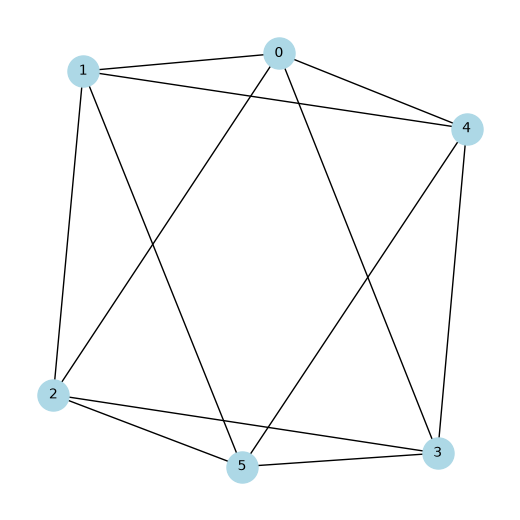

In [99]:
import PySimplicial.utils

octahedron = [(0,1,2), (0,2,3), (0,3,4), (0,4,1),(5,2,1), (5,3,2), (5,4,3), (5,1,4)] #8 triangles list
PySimplicial.utils.visualize_triangulation_2D(octahedron)

Its *basic 2D spring_layout based function* (spring_layout have some **restrictions**, like, **we cant visualize torus correctly**, but with figures without holes it works correct). Next is the same function but work with **tetrahedrons**

In [100]:
def visualize_triangulation_3D(tris): # 3D visualization
    G = networkx.Graph() # create empty graph
    for a,b,c,d in tris: # add edges from triangle
        G.add_edge(a,b)
        G.add_edge(a,c)
        G.add_edge(a,d)
        G.add_edge(b,c)
        G.add_edge(b,d)
        G.add_edge(c,d)
    pos = networkx.spring_layout(G, seed=1) # define vertices position
    plt.figure(figsize=(5,5))
    networkx.draw(G, pos, with_labels=True, node_color="lightblue", node_size=500, font_size=10)
    plt.axis("off")
    plt.show()

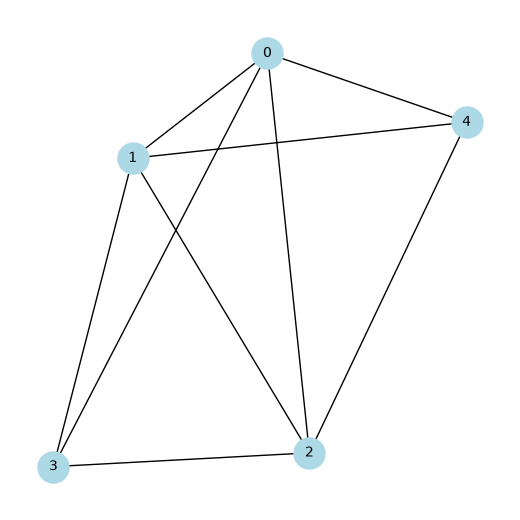

In [101]:
tetrahedron = [(0, 1, 2, 3),(0, 1, 2, 4)]

PySimplicial.utils.visualize_triangulation_3D(tetrahedron)

The next feature it is a Pachner Moves, the triangulations of the Piecewise-Linear Manifolds (see more in [OCSSN Mathemathical Introduction](https://github.com/kaifczxc-lab/OCSSN/blob/SiritoriProjects/OCSSN-Maths-Introduction.md)). In pysimplicial we have all 2D & 3D moves

Basic octahedron=[(0, 1, 2), (0, 2, 3), (0, 3, 4), (0, 4, 1), (5, 2, 1), (5, 3, 2), (5, 4, 3), (5, 1, 4)]
Pachner_move_2_2 Octahedron=[(0, 1, 2), (0, 2, 3), (0, 4, 1), (5, 2, 1), (5, 3, 2), (5, 1, 4), (3, 0, 5), (0, 4, 5)]


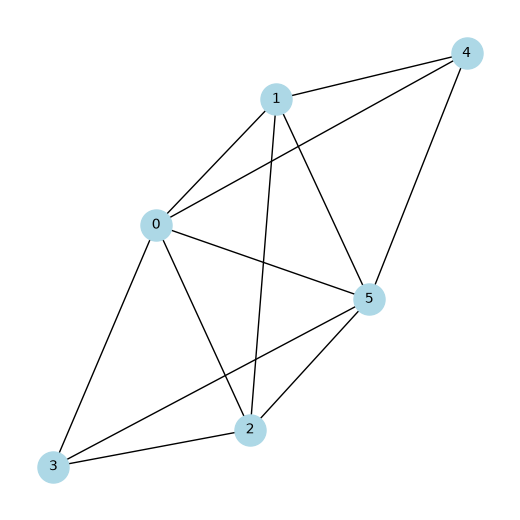

In [102]:
from collections import defaultdict
import random    
from collections import Counter

def move_2_2(tris):
    # we need to construct a mapping : edge -> list of tris containing it
    ett = defaultdict(list) # edge to tris
    for idx, (a,b,c) in enumerate(tris): # first triangle: (0, (0,1,2)) ; second triangle: (1, (0,2,3))
        # for each triangle, we iterate over its three edges for ensure that the edges (a,b) and (b,a) are considered the same
        for edge in [tuple(sorted((a,b))), tuple(sorted((b,c))), tuple(sorted((a,c)))]:
            ett[edge].append(idx) # add the index of the current triangle to the list of triangles that own this edge
    exist=set(ett.keys()) # set of all exist edges ; it is necessary to check whether a new diagonal already exists
    # choose an edge that has exactly two tris
    inter=[e for e, tris in ett.items() if len(tris) == 2] # A move 2/2 can only be done on an edge that is adjacent to exactly two triangles
    random.shuffle(inter)
    #edge=random.choice(inter) # choose random
    for edge in inter:
        t1_idx,t2_idx=ett[edge]
        a,b = edge # a,b = end of this edge
        t1 = tris[t1_idx]
        t2 = tris[t2_idx]
        c = [v for v in t1 if v != a and v != b]
        d = [v for v in t2 if v != a and v != b]
        if not c or not d: # empty check
            continue
        c,d = c[0], d[0]
        new_edge=tuple(sorted((c,d)))
        if c==d or new_edge in exist:
            continue
        new_triangles = [t for i, t in enumerate(tris) if i != t1_idx and i != t2_idx] # all triangles except those with indices 0 and 1 will be empty []
        new_triangles.append((a,c,d))
        new_triangles.append((c,b,d))
        return new_triangles
    return tris

Pachner_move_2_2 = move_2_2(octahedron)
print(f"Basic octahedron={octahedron}")
print(f"Pachner_move_2_2 Octahedron={Pachner_move_2_2}")
visualize_triangulation_2D(Pachner_move_2_2)

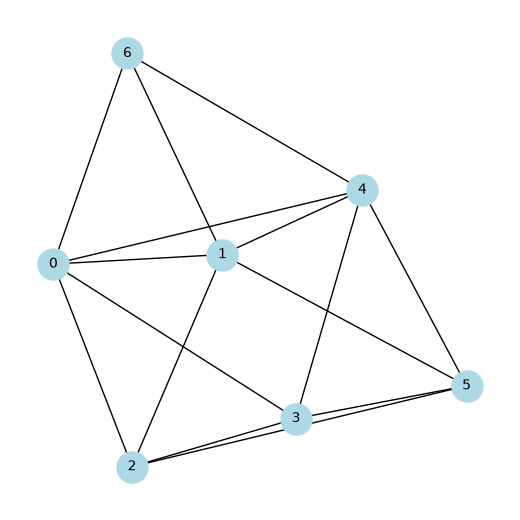

In [103]:

def p_1_3(tris):
    index = random.randrange(len(tris))
    a,b,c = tris[index]
    n_v = max(max(t) for t in tris) + 1 # +1 gives guaranteed unique ID
    n_triangles = [t for i,t in enumerate(tris) if i != index]
    n_triangles += [(a,b,n_v), (b,c,n_v), (a,c,n_v)]
    return n_triangles 

Pachner_move_1_3 = PySimplicial.utils.move_1_3(octahedron)
PySimplicial.utils.visualize_triangulation_2D(Pachner_move_1_3)

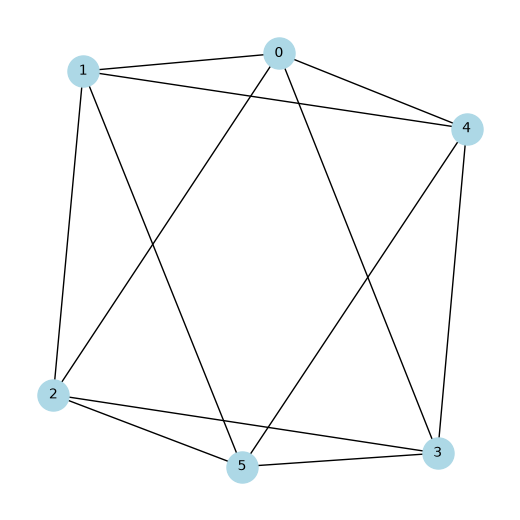

In [104]:
def move_3_1(tris):
    e_count = Counter()
    for (a,b,c) in tris:
        for edge in [tuple(sorted((a,b))), tuple(sorted((b,c))), tuple(sorted((a,c)))]:
            e_count[edge] += 1
    vert_tris = defaultdict(list)
    for i, (a,b,c) in enumerate(tris):
        for v in (a,b,c):
            vert_tris[v].append(i)
    for v, incident in vert_tris.items():
        if len(incident) != 3:
            continue
        others = []
        for i in incident:
            a,b,c = tris[i]
            for u in (a,b,c):
                if u != v and u not in others:
                    others.append(u)
        if len(others) != 3:
            continue
        o1,o2,o3 = others
        new_tri = (o1,o2,o3)
        existing_edges = set(tuple(sorted((a,b))) for a,b,c in tris
                            for a,b in [(a,b), (b,c), (a,c)])
        if tuple(sorted((o1, o2))) in existing_edges and tuple(sorted((o2, o3))) in existing_edges and tuple(sorted((o1, o3))) in existing_edges:
            pass
        new_triangles = [t for i, t in enumerate(tris) if i not in incident]
        new_triangles.append(new_tri)
        return new_triangles
    return None

Pachner_move_3_1 = PySimplicial.utils.move_3_1(Pachner_move_1_3)
PySimplicial.utils.visualize_triangulation_2D(Pachner_move_3_1)


Now from 2D we move to 3D Pachner Moves, there are 4 types: 1-4; 4-1; 2-3; 3-2

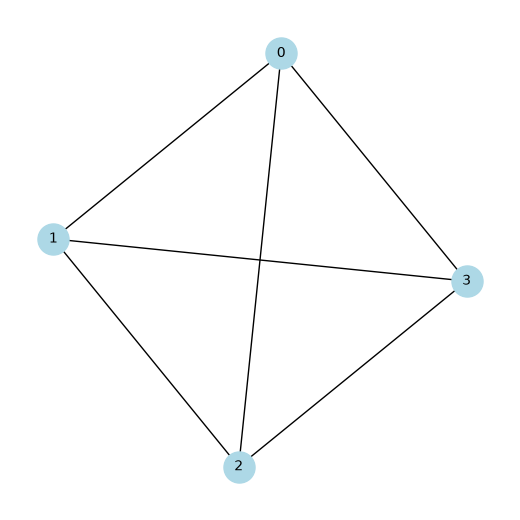

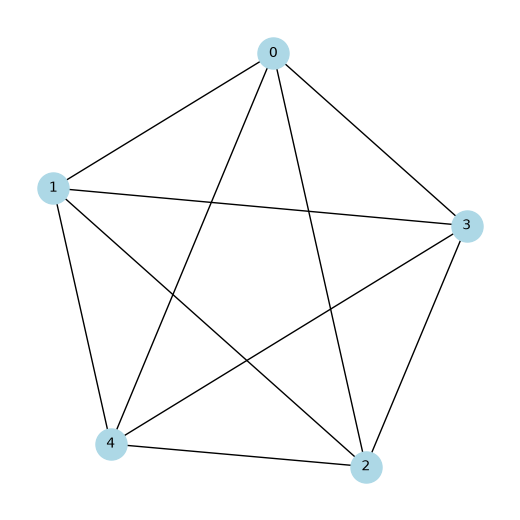

In [105]:
def move_1_4(tetrahedron):
    index = random.randrange(len(tetrahedron))
    a,b,c,d = tetrahedron[index]
    n_v = max(max(t) for t in tetrahedron) + 1 # +1 gives guaranteed unique ID
    n_triangles = [t for i,t in enumerate(tetrahedron) if i != index]
    n_triangles += [(a, b, c, n_v),(a, b, d, n_v),(a, c, d, n_v),(b, c, d, n_v)]
    return n_triangles 

one_tetrahedron = [(0, 1, 2, 3)]
PySimplicial.utils.visualize_triangulation_3D(one_tetrahedron)

Pachner_move_1_4 = PySimplicial.utils.move_1_4(one_tetrahedron)
PySimplicial.utils.visualize_triangulation_3D(Pachner_move_1_4)

The move 4-1 is the **reverse** of 1-4 (that is, when applied to a figure that was triangulated by the move 1-4, we return to the **original shape**) ; The same situation with 2-3 and 3-2

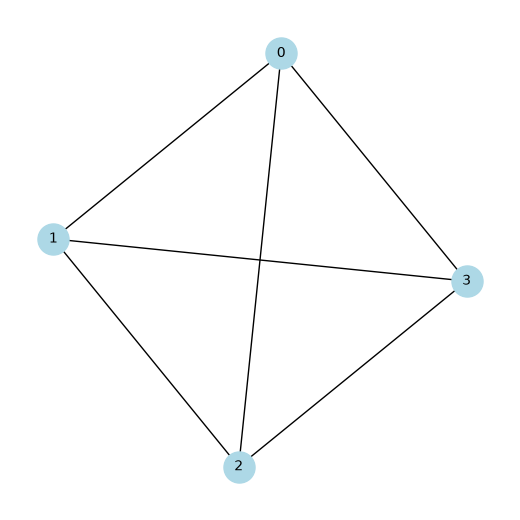

In [106]:
def move_4_1(tetrahedron):
    vert_tetrahedron = defaultdict(list)
    for i, (a,b,c,d) in enumerate(tetrahedron):
        for v in (a,b,c,d):
            vert_tetrahedron[v].append(i)
    for v, incident in vert_tetrahedron.items():
        if len(incident) != 4:
            continue
        others = []
        for i in incident:
            a,b,c,d = tetrahedron[i]
            for u in (a,b,c,d):
                if u != v and u not in others:
                    others.append(u)
        if len(others) != 4:
            continue
        o1,o2,o3,o4 = others
        new_tetra = (o1,o2,o3,o4)
        new_triangles = [t for i, t in enumerate(tetrahedron) if i not in incident]
        new_triangles.append(new_tetra)
        return new_triangles
    return None

Pachner_move_4_1 = PySimplicial.utils.move_4_1(Pachner_move_1_4)
PySimplicial.utils.visualize_triangulation_3D(Pachner_move_4_1)

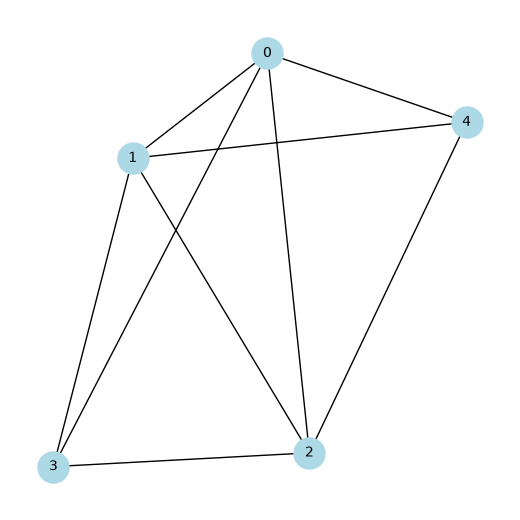

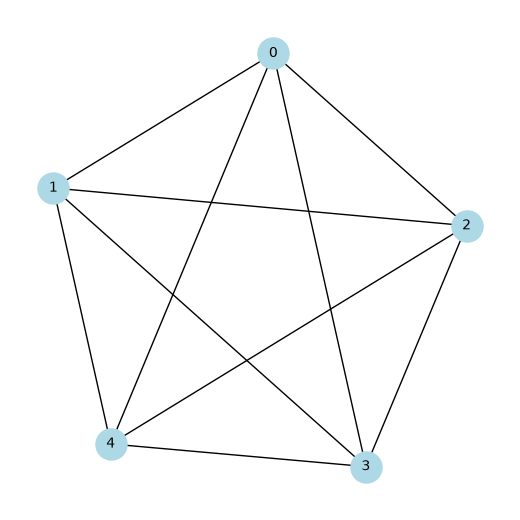

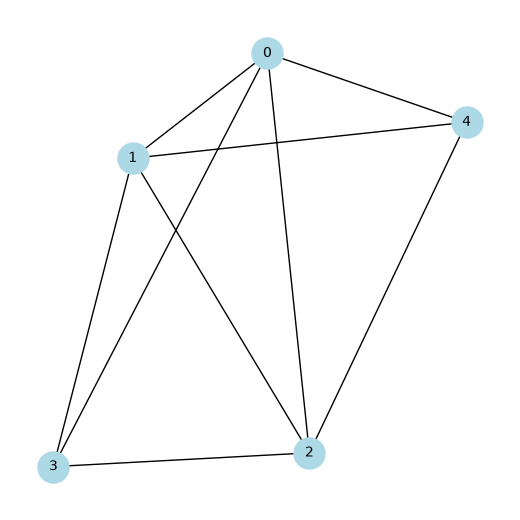

In [107]:
def move_2_3(tetrahedron):
    # we need to construct a mapping : edge -> list of tris containing it
    ett = defaultdict(list) # edge to tris
    for idx, (a,b,c,d) in enumerate(tetrahedron):
        for edge in [tuple(sorted((a,b,c))), tuple(sorted((a,b,d))), tuple(sorted((a,c,d))), tuple(sorted((b,c,d)))]:
            ett[edge].append(idx) # add the index of the current triangle to the list of triangles that own this edge
    exist=set(ett.keys()) # set of all exist edges ; it is necessary to check whether a new diagonal already exists
    # choose an edge that has exactly two tris
    inter=[e for e, tetrahedron in ett.items() if len(tetrahedron) == 2]
    random.shuffle(inter)
    #edge=random.choice(inter) # choose random
    for edge in inter:
        t1_idx,t2_idx=ett[edge]
        a,b,c = edge # a,b,c = end of this edge
        t1 = tetrahedron[t1_idx]
        t2 = tetrahedron[t2_idx]
        d = [v for v in t1 if v not in edge][0]
        e = [v for v in t2 if v not in edge][0]
        new_tetrahedrons = [t for i, t in enumerate(tetrahedron) if i != t1_idx and i != t2_idx] # all triangles except those with indices 0 and 1 will be empty []
        new_tetrahedrons.append((a, b, d, e))
        new_tetrahedrons.append((b, c, d, e))
        new_tetrahedrons.append((a, c, d, e))
        return new_tetrahedrons
    return tetrahedron

def move_3_2(tetrahedron):
    edge_to_tetrahedrons = defaultdict(list)
    for idx, tetrahedron_ in enumerate(tetrahedron):
        a, b, c, d = tetrahedron_
        for edge in [(a,b), (a,c), (a,d), (b,c), (b,d), (c,d)]:
            edge = tuple(sorted(edge))
            edge_to_tetrahedrons[edge].append(idx)
    for edge, tetrahedron_idx in edge_to_tetrahedrons.items():
        if len(tetrahedron_idx) != 3:
            continue
        i1, i2, i3 = tetrahedron_idx
        t1 = tetrahedron[i1]
        t2 = tetrahedron[i2]
        t3 = tetrahedron[i3]
        u, v = edge
        exts = []
        for t in (t1, t2, t3):
            pair = [x for x in t if x not in (u, v)]
            exts.append(tuple(sorted(pair)))
        all_ext = list({x for pair in exts for x in pair})
        if len(all_ext) != 3:
            continue
        a, b, c = sorted(all_ext)
        new_t1 = tuple(sorted((a, b, c, u)))
        new_t2 = tuple(sorted((a, b, c, v)))
        result = [t for i, t in enumerate(tetrahedron) if i not in tetrahedron_idx]
        result.extend([new_t1, new_t2])
        return result
    return tetrahedron


tetrahedron = [(0, 1, 2, 3),(0, 1, 2, 4)] # Visualize original figure
PySimplicial.utils.visualize_triangulation_3D(tetrahedron)

Pachner_move_2_3 = PySimplicial.utils.move_2_3(tetrahedron) # visualize the same figure but with Pachner Move 2-3 triangulation
PySimplicial.utils.visualize_triangulation_3D(Pachner_move_2_3)

Pachner_move_3_2 = PySimplicial.utils.move_3_2(Pachner_move_2_3) # return this modify to basic form
PySimplicial.utils.visualize_triangulation_3D(Pachner_move_3_2)



This library's code contains more than just triangulation visualizations, and currently only has three torus and bottle of klein generators 

1. A combinatorial torus, which is well suited for calculations (datasets, for example), but is somewhat difficult to visualize

2. A geometric torus, which is difficult to use for calculations, but can be visualized using a custom function (there's no built-in function yet)

3. A combinatorial torus 3D (contains tetrahedrons instead triangles)

4. Geometric 3D bottle of klein (can be visualized by custom function, there's no built-in function yet)

In [108]:
import numpy as np
import matplotlib.pyplot as plt


def combinatorial_torus(m, n):
    def vid(r,c):
        return (r % m) * n + (c % n)
    tris = []
    for r in range(m):
        for c in range(n):
            v00 = vid(r,c)
            v01 = vid(r, c+1)
            v10 = vid(r+1, c)
            v11 = vid(r+1,c+1)
            tris.append((v00, v01, v10))
            tris.append((v01, v11, v10))
    return tris

def geometry_torus(m,n,R,r):
    result = {}
    for id in range(m * n):
        row = id // n
        col = id % n
        u = 2 * np.pi * row / m
        v = 2 * np.pi * col / n
        x = (R + r * np.cos(v)) * np.cos(u)
        y = (R + r * np.cos(v)) * np.sin(u)
        z = r * np.sin(v)
        result[id] = (x,y,z)
    return result

def combinatorial_torus_3D(m, n, p):
    def vid3D(i, j, k):
        return ((i % m) * n + (j % n)) * p + (k % p)
    tets = []
    for i in range(m):
        for j in range(n):
            for k in range(p):
                v000 = vid3D(i, j, k)
                v100 = vid3D(i+1, j, k)
                v010 = vid3D(i, j+1, k)
                v001 = vid3D(i, j, k+1)
                v110 = vid3D(i+1, j+1, k)
                v101 = vid3D(i+1, j, k+1)
                v011 = vid3D(i, j+1, k+1)
                v111 = vid3D(i+1, j+1, k+1)
                tets.extend([(v000, v100, v110, v111),(v000, v100, v101, v111),(v000, v010, v110, v111),(v000, v010, v011, v111),(v000, v001, v101, v111),(v000, v001, v011, v111)])
    return tets


cos = np.cos
sin = np.sin
sqrt = np.sqrt
pi = np.pi


def geometry_bottle_of_klein(u, v):
    """
    returns point cloud / surface
    """
    half = (0 <= u) & (u < pi)
    r = 4*(1 - cos(u)/2)
    x = 6*cos(u)*(1 + sin(u)) + r*cos(v + pi)
    x[half] = ((6*cos(u)*(1 + sin(u)) + r*cos(u)*cos(v))[half])
    y = 16 * sin(u)
    y[half] = (16*sin(u) + r*sin(u)*cos(v))[half]
    z = r * sin(v)
    return x, y, z

combinatorial_torus_2D = PySimplicial.utils.combinatorial_torus(3,3)
print("combinatorial torus 2d")
print(combinatorial_torus_2D)

geometry_torus_3D = PySimplicial.utils.geometry_torus(3,3,2,1)
print("geometry torus 3d")
print(geometry_torus_3D)

combinatorial_torus_3D = PySimplicial.utils.combinatorial_torus_3D(3,3,3)
print("combinatorial torus 3d")
print(combinatorial_torus_3D)

u, v = np.meshgrid(np.linspace(0, 2*np.pi, 3),np.linspace(0, 2*np.pi, 3))
bottle_of_klein = PySimplicial.utils.geometry_bottle_of_klein(u, v)
print("bottle of klein")
print(bottle_of_klein)

combinatorial torus 2d
[(0, 1, 3), (1, 4, 3), (1, 2, 4), (2, 5, 4), (2, 0, 5), (0, 3, 5), (3, 4, 6), (4, 7, 6), (4, 5, 7), (5, 8, 7), (5, 3, 8), (3, 6, 8), (6, 7, 0), (7, 1, 0), (7, 8, 1), (8, 2, 1), (8, 6, 2), (6, 0, 2)]
geometry torus 3d
{0: (np.float64(3.0), np.float64(0.0), np.float64(0.0)), 1: (np.float64(1.5000000000000002), np.float64(0.0), np.float64(0.8660254037844387)), 2: (np.float64(1.4999999999999996), np.float64(0.0), np.float64(-0.8660254037844385)), 3: (np.float64(-1.4999999999999993), np.float64(2.598076211353316), np.float64(0.0)), 4: (np.float64(-0.7499999999999998), np.float64(1.2990381056766582), np.float64(0.8660254037844387)), 5: (np.float64(-0.7499999999999994), np.float64(1.2990381056766578), np.float64(-0.8660254037844385)), 6: (np.float64(-1.5000000000000013), np.float64(-2.5980762113533156), np.float64(0.0)), 7: (np.float64(-0.7500000000000008), np.float64(-1.299038105676658), np.float64(0.8660254037844387)), 8: (np.float64(-0.7500000000000004), np.float64(-

The code also has one interesting feature: **converters of information in the form of meshes into data types understandable for popular neural network architectures** (graphs, tensors, vectors)

All of this came from OCSSN, because I needed the data to be understandable by all networks when comparing (in order to attempt to calculate a topological invariant)

In [109]:
# Here we will write functions for converting geometric information (meshes) into input data understandable for popular neural network architectures

import torch
from collections import defaultdict

def relabel(tris):
    map = {}
    n_tris = []
    for a,b,c in tris:
        for v in (a,b,c):
            if v not in map:
                map[v] = len(map)
        n_tris.append((map[a], map[b], map[c]))
    return n_tris

def converter_for_gnn(tris):
    tris = relabel(tris)
    num_nodes = max(max(t) for t in tris) + 1
    A = torch.zeros((num_nodes, num_nodes))
    for (u,v,w) in tris:
        A[u,v]=A[v,u]=1.0; A[v,w]=A[w,v]=1.0; A[u,w]=1.0
    s = A.sum()
    degree = (A.sum(dim=1, keepdim=True) / (s + 1e-8))
    L = torch.cat([degree, torch.ones(num_nodes, 1)], dim=1)
    return A / (s + 1e-8), L

def converter_for_tnn(tris, N):
    tris = relabel(tris)
    A = torch.zeros((N,N))
    for (u,v,w) in tris:
        A[u,v]=A[v,u]=1.0; A[v,w]=A[w,v]=1.0; A[u,w]=A[w,u]=1.0
    deg = A.sum(dim=1)
    deg1 = torch.where(deg > 0, deg.pow(-0.5), torch.zeros_like(deg))
    D = torch.diag(deg1)
    A_norm = D @ A @ D 
    return A_norm

def converter_for_mlp(tris, return_g=False):
    """
    Here we calculate the Histogram of vertex degrees, euler's characteristics, tris_per_vertex (F / V) and average deegree number

    Histogram of verted degrees algorithm: 
        
        >>> get the degree count for every node in tris

        >>> count how many nodes share each degree value
    
    Euler's Charactertic formula (2D):

        >>> V = unique vertices, E = unique edges, F = number of faces, g = surface genus

        >>> x = V - E + F = 2 - 2g
    
    Calculating tris_per_vertex:

        >>> Number of faces / unique vertices

    Calculating average degree:

        >>> 2 * unique edges / unique vertices
    """

    F = len(tris) # In example of octahedron: F=8
    vert = set() # set() guarantees no duplicates
    for (a,b,c) in tris: # calculate V
        vert.add(a)
        vert.add(b)
        vert.add(c)
    V = len(vert) # In example of octahedron: V=6 
    edges = set()
    for (a,b,c) in tris: # calculate E
        # if 2 triangles share one edge ; Example. Upper: 1-2 & Lower: 2-1 ; They will be written in edges as (1,2) 
        edges.add(tuple(sorted((a,b)))) # About python base: tuple() is list ensures that it cannot be modified after creation ; sorted(()) sorts values ​​in ascending order
        edges.add(tuple(sorted((b,c))))
        edges.add(tuple(sorted((a,c))))
    E = len(edges) # In example of octahedron: E=12
    g = (2 - (V-E+F)) // 2 # Pick our values: 6 - 12 + 8 = 2 ==> 2 - 2 = 0 // 2 ==> g = 0 
    avg_degree = 2 * E / V
    tpv = F / V
    vertice_neighbors = defaultdict(set)
    for (a,b,c) in tris:
        vertice_neighbors[a].update([b,c])
        vertice_neighbors[b].update([a,c])
        vertice_neighbors[c].update([a,b])
    deg = [len(vertice_neighbors[v]) for v in vertice_neighbors]
    bins = [0] * 4
    for a in deg:
        if a <= 3:
            bins[0] += 1
        elif a <= 5:
            bins[1] += 1
        elif a <= 7:
            bins[2] += 1
        else:
            bins[3] += 1
    if return_g:
        return F, V, E, g, bins[0], bins[1], bins[2], bins[3], avg_degree, tpv
    else:
        return F, V, E, bins[0], bins[1], bins[2], bins[3], avg_degree, tpv

octahedron_for_relabel = [(10, 50, 15),(10, 15, 25),(10, 25, 40),(10, 40, 50),(90, 15, 50),(90, 25, 15),(90, 40, 25),(90, 50, 40)]
relabel_ = PySimplicial.utils.relabel(octahedron_for_relabel)
print("RELABEL")
print(relabel_)

converter_GNN_2D = PySimplicial.utils.converter_for_gnn(relabel_)
print("CONVERTER GNN")
print(converter_GNN_2D)

converter_TNN_2D = PySimplicial.utils.converter_for_tnn(relabel_, 6)
print("CONVERTER TNN")
print(converter_TNN_2D)

converter_MLP_2D = PySimplicial.utils.converter_for_mlp(relabel_, return_g=True)
print("CONVERTED MLP")
print(converter_MLP_2D)


RELABEL
[(0, 1, 2), (0, 2, 3), (0, 3, 4), (0, 4, 1), (5, 2, 1), (5, 3, 2), (5, 4, 3), (5, 1, 4)]
CONVERTER GNN
(tensor([[0.0000, 0.0417, 0.0417, 0.0417, 0.0417, 0.0000],
        [0.0417, 0.0000, 0.0417, 0.0000, 0.0417, 0.0417],
        [0.0417, 0.0417, 0.0000, 0.0417, 0.0000, 0.0417],
        [0.0417, 0.0000, 0.0417, 0.0000, 0.0417, 0.0417],
        [0.0417, 0.0417, 0.0000, 0.0417, 0.0000, 0.0417],
        [0.0000, 0.0417, 0.0417, 0.0417, 0.0417, 0.0000]]), tensor([[0.1667, 1.0000],
        [0.1667, 1.0000],
        [0.1667, 1.0000],
        [0.1667, 1.0000],
        [0.1667, 1.0000],
        [0.1667, 1.0000]]))
CONVERTER TNN
tensor([[0.0000, 0.2500, 0.2500, 0.2500, 0.2500, 0.0000],
        [0.2500, 0.0000, 0.2500, 0.0000, 0.2500, 0.2500],
        [0.2500, 0.2500, 0.0000, 0.2500, 0.0000, 0.2500],
        [0.2500, 0.0000, 0.2500, 0.0000, 0.2500, 0.2500],
        [0.2500, 0.2500, 0.0000, 0.2500, 0.0000, 0.2500],
        [0.0000, 0.2500, 0.2500, 0.2500, 0.2500, 0.0000]])
CONVERTED MLP
(8,

And 3D versions (3D because it with support tetrahedrons)

In [110]:
def relabel_3D(tetrahedron):
    map = {}
    n_tetrahedron = []
    for a,b,c,d in tetrahedron:
        for v in (a,b,c,d):
            if v not in map:
                map[v] = len(map)
        n_tetrahedron.append((map[a], map[b], map[c], map[d]))
    return n_tetrahedron


def converter_for_gnn_3D(tetrahedron):
    """
    Here we calculate the matrix from all vertices of tetrahedron-mesh, sum it and return:

    return A / (s + 1e-8), L # A / 10 (we got matrix B), L

    where: 

    num_nodes = max(max(t) for t in tetrahedron)

    A = torch.zeros((num_nodes, num_nodes))
    
    L = torch.cat([degree, torch.ones(num_nodes, 1)], dim=1)

    s = A.sum()

    """
    tetrahedron = relabel_3D(tetrahedron)
    num_nodes = max(max(t) for t in tetrahedron) + 1
    A = torch.zeros((num_nodes, num_nodes))
    for (a,b,c,d) in tetrahedron:
        A[a,b]=A[b,a]=1.0 ; A[a,c]=A[c,a]=1.0 ; A[a,d]=A[d,a]=1.0;A[b,c]=A[c,b]=1.0 ; A[b,d]=A[d,b]=1.0;A[c,d]=A[d,c]=1.0
    s = A.sum()
    degree = (A.sum(dim=1, keepdim=True) / (s + 1e-8))
    L = torch.cat([degree, torch.ones(num_nodes, 1)], dim=1)
    return A / (s + 1e-8), L


def converter_for_tnn_3D(tetrahedron, N):
    """
    Here we calculate the balanced and normalized adjacency matrix from tetrahedrons-mesh data
    """
    tetrahedron = relabel_3D(tetrahedron)
    A = torch.zeros((N,N))
    for (a,b,c,d) in tetrahedron:
        A[a,b]=A[b,a]=1.0 ; A[a,c]=A[c,a]=1.0 ; A[a,d]=A[d,a]=1.0;A[b,c]=A[c,b]=1.0 ; A[b,d]=A[d,b]=1.0;A[c,d]=A[d,c]=1.0
    deg = A.sum(dim=1)
    deg1 = torch.where(deg > 0, deg.pow(-0.5), torch.zeros_like(deg))
    D = torch.diag(deg1)
    A_norm = D @ A @ D 
    return A_norm

def converter_for_mlp_3D(tetrahedron, return_x=False, U=3, W=5, V=7):
    """
    Here we calculate the Histogram of vertex degrees, euler's characteristics, tris_per_vertex (F / V) and average deegree number

    U,W,V - Histogram of vertex degrees bins where U - smallest ; W - middle ; V - highest. Can be customized, but the basic values ​​are 3, 5, 7

    Histogram of vertex degrees algorithm: 
        
        >>> get the degree count for every node in tris

        >>> count how many nodes share each degree value
    
    Euler's Charactertic formula (2D):

        >>> V = unique vertices, E = unique edges, F = number of faces, g = surface genus

        >>> x = V - E + F = 2 - 2g
    
    Calculating tris_per_vertex:

        >>> Number of faces / unique vertices

    Calculating average degree:

        >>> 2 * unique edges / unique vertices
    """
    T = len(tetrahedron)
    # In example of octahedron: F=8
    vert = set() # set() guarantees no duplicates
    for (a,b,c,d) in tetrahedron: # calculate V
        vert.add(a)
        vert.add(b)
        vert.add(c)
        vert.add(d)
    V = len(vert) # In example of octahedron: V=6 
    edges = set()
    for (a,b,c,d) in tetrahedron: # calculate E
        # if 2 triangles share one edge ; Example. Upper: 1-2 & Lower: 2-1 ; They will be written in edges as (1,2) 
        edges.add(tuple(sorted((a,b)))), 
        edges.add(tuple(sorted((a,c)))), 
        edges.add(tuple(sorted((a,d)))), 
        edges.add(tuple(sorted((b,c)))),
        edges.add(tuple(sorted((b,d)))), 
        edges.add(tuple(sorted((c,d))))
    E = len(edges) # In example of octahedron: E=12
    faces=set()
    for (a,b,c,d) in tetrahedron:
        faces.add(tuple(sorted((a,b,c))))
        faces.add(tuple(sorted((a,b,d))))
        faces.add(tuple(sorted((a,c,d))))
        faces.add(tuple(sorted((b,c,d))))

    F = len(faces)
    x = V-E+F-T # Pick our values: 6 - 12 + 8 = 2 ==> 2 - 2 = 0 // 2 ==> g = 0 
    avg_degree = 2 * E / V
    tpv = F / V
    vertice_neighbors = defaultdict(set)
    for (a,b,c,d) in tetrahedron:
        vertice_neighbors[a].update([b,c,d])
        vertice_neighbors[b].update([a,c,d])
        vertice_neighbors[c].update([a,b,d])
        vertice_neighbors[d].update([a,b,c])
    deg = [len(vertice_neighbors[v]) for v in vertice_neighbors]
    bins = [0] * 4
    for a in deg:
        if a <= U:
            bins[0] += 1
        elif a <= W:
            bins[1] += 1
        elif a <= V:
            bins[2] += 1
        else:
            bins[3] += 1
    if return_x:
        return F, V, E, x, bins[0], bins[1], bins[2], bins[3], avg_degree, tpv
    else:
        return F, V, E, bins[0], bins[1], bins[2], bins[3], avg_degree, tpv

tetrahedron_for_relabel = [(100,200,300,400),(0,200,300,400),(0,100,300,400),(0,100,200,400),(0,100,200,300)]
relabel_3D_ = PySimplicial.utils.relabel_3D(tetrahedron_for_relabel)
print("RELABEL 3D")
print(relabel_3D_)

converter_GNN_3D = PySimplicial.utils.converter_for_gnn_3D(relabel_3D_)
print("CONVERTER GNN 3D")
print(converter_GNN_3D)

converter_TNN_3D = PySimplicial.utils.converter_for_tnn_3D(relabel_3D_, 6)
print("CONVERTER TNN 3D")
print(converter_TNN_3D)

converter_MLP_3D = PySimplicial.utils.converter_for_mlp_3D(relabel_3D_, return_x=True)
print("CONVERTED MLP 3D")
print(converter_MLP_3D)

RELABEL 3D
[(0, 1, 2, 3), (4, 1, 2, 3), (4, 0, 2, 3), (4, 0, 1, 3), (4, 0, 1, 2)]
CONVERTER GNN 3D
(tensor([[0.0000, 0.0500, 0.0500, 0.0500, 0.0500],
        [0.0500, 0.0000, 0.0500, 0.0500, 0.0500],
        [0.0500, 0.0500, 0.0000, 0.0500, 0.0500],
        [0.0500, 0.0500, 0.0500, 0.0000, 0.0500],
        [0.0500, 0.0500, 0.0500, 0.0500, 0.0000]]), tensor([[0.2000, 1.0000],
        [0.2000, 1.0000],
        [0.2000, 1.0000],
        [0.2000, 1.0000],
        [0.2000, 1.0000]]))
CONVERTER TNN 3D
tensor([[0.0000, 0.2500, 0.2500, 0.2500, 0.2500, 0.0000],
        [0.2500, 0.0000, 0.2500, 0.2500, 0.2500, 0.0000],
        [0.2500, 0.2500, 0.0000, 0.2500, 0.2500, 0.0000],
        [0.2500, 0.2500, 0.2500, 0.0000, 0.2500, 0.0000],
        [0.2500, 0.2500, 0.2500, 0.2500, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000]])
CONVERTED MLP 3D
(10, 5, 10, 0, 0, 5, 0, 0, 4.0, 2.0)


Library has another interesting feature from TQFT, a state-sum based on [Aaron D. Lauda. Hendryk Pfeiffer (2006): State sum construction of two-dimensional open-closed Topological Quantum Field Theories](https://arxiv.org/abs/math/0602047)

In [111]:
import opt_einsum
import numpy as np

def state_sum(C, b_inv, v_p, g_edges, open_ports=()): # pass values from graph() and C (c3) and b_inv

    """
    This function deserves a separate discussion:

    it implements convolution over triangulation, but by itself does not guarantee topological invariance. Invariance depends on the tensors C and b_inv, which in the trained version may not satisfy the Frobenius axioms. That is, for the correct result you need a fixed Frobenius algebra
    
    """
    ops = [] # main list for opt_einsum, here we will add all arguments
    for (a,b,c) in v_p: # as example let take v_p = [(0,1,2),(3,4,5)]
        ops += [C, (a,b,c)] # for every unique port ID lets compare the index =>
        # => (t0,t1,t2,t3,t4,t5) => ops += [C, (0,1,2)] => C_t0,t1,t2 ; ops += [C,(3,4,5)] => C_t3,t4,t5 ; C_a,b,c for each triangle
    for (x,y) in g_edges: # g_edges=[1,5]
        ops += [b_inv, (x,y)] # b_inv = (B^-1)_t1,t5
    ops += [tuple(open_ports)] # open_ports=[0,2,3,4]
    # After all: Z_T0 = sum_t1,t2,t3,t4,t5 C_t0,t1,t2 * C_t3,t4,t5 * (B^-1)_t1,t5
    return opt_einsum.contract(*ops, optimize="greedy") # opt_einsum its just better version of basic einsum, it searches the best way to sum huge values

C = np.array([[[1.,0.],[0.,1.]],[[0.,1.],[1.,0.]]])
b_inv = np.array([[1.,0.],[0.,1.]])

# Two triangles glued along all 3 edges to closed surface, without open_ports
Z_before = state_sum(C, b_inv, [(0,1,2),(3,4,5)], [(0,3),(1,4),(2,5)], ())

# Same closed topology, but different gluing pattern
Z_after = state_sum(C, b_inv, [(0,1,2),(3,4,5)], [(0,4),(1,3),(2,5)], ())

print(Z_before, Z_after, np.isclose(Z_before, Z_after))

4.0 4.0 True


Also, we can compute the number of genus and connected components of our figure by using ```compute_connected_components_3D, compute_genus_2D```

In [112]:

# pick fugire (list) and calculate type of surface g by Eulers Characteristic: x = V - E + F = 2 - 2g
# V = unique vertices, E = unique edges, F = number of faces, g = surface genus

def compute_genus_2D(triangle_mesh2D):

    """
    Calculates the type of surface in 2D mesh and depends of number says how much there holes

    The Euler's Characteristics has invented by Leonard Euler and looks like that x = V - E + F = 2 - 2g, so, we can find g if we change this formula (Assumes the mesh is a closed orientable surface)

    Vertices and edges are counted uniquely

    Parameters
    ----------
    triangle_mesh2D : list of tuple

        Enter triangulation in form list of triangles

        Every triangle is a tuple of three integers (vertex indices)
    
    Returns
    -------

    Natural number that says the genus of the surface

    Examples
    --------

    >>> octahedron = [(0,1,2), (0,2,3), (0,3,4), (0,4,1),(5,2,1), (5,3,2), (5,4,3), (5,1,4)]
    >>> print(compute_genus_2D(octahedron))
    0

    """
    F = len(triangle_mesh2D) # In example of octahedron: F=8
    vert = set() # set() guarantees no duplicates
    for (a,b,c) in triangle_mesh2D: # calculate V
        vert.add(a)
        vert.add(b)
        vert.add(c)
    V = len(vert) # In example of octahedron: V=6 
    edges = set()
    for (a,b,c) in triangle_mesh2D: # calculate E
        # if 2 triangles share one edge ; Example. Upper: 1-2 & Lower: 2-1 ; They will be written in edges as (1,2) 
        edges.add(tuple(sorted((a,b)))) # About python base: tuple() is list ensures that it cannot be modified after creation ; sorted(()) sorts values ​​in ascending order
        edges.add(tuple(sorted((b,c))))
        edges.add(tuple(sorted((a,c))))
    E = len(edges) # In example of octahedron: E=12
    g = (2 - (V-E+F)) // 2 # Pick our values: 6 - 12 + 8 = 2 ==> 2 - 2 = 0 // 2 ==> g = 0 
    return g


def compute_connected_components_3D(tetrahedron_mesh3D):
    """
    Calculates the number of connected components of a 3D space
    
    Formula: x = V-E+F-T

    Where:

    V is unique vertices

    E is unique edges

    F is unique faces

    T is amount of tetrahedrons

    Parameters
    ----------

    tetrahedron_mesh3D : list of tuple

        Enter triangulation in form list of tetrahedrons

        Every triangle is a tuple of four integers (vertex indices)

    Returns
    -------

    Natural number that says amount of connected components of a 3D space
    
    Examples
    --------

    >>> tetrahedron = [(0, 1, 2, 3),(0, 1, 2, 4)]
    >>> print(compute_genus_3D(tetrahedra))
    1
    
    """
    T = len(tetrahedron_mesh3D)
    vert = set()
    for (a,b,c,d) in tetrahedron_mesh3D:
        vert.add(a)
        vert.add(b)
        vert.add(c)
        vert.add(d)
    V = len(vert)
    edges = set()
    for (a,b,c,d) in tetrahedron_mesh3D:
        edges.add(tuple(sorted((a,b)))), 
        edges.add(tuple(sorted((a,c)))), 
        edges.add(tuple(sorted((a,d)))), 
        edges.add(tuple(sorted((b,c))))
        edges.add(tuple(sorted((b,d)))), 
        edges.add(tuple(sorted((c,d))))
    E = len(edges)
    faces=set()
    for (a,b,c,d) in tetrahedron_mesh3D:
        faces.add(tuple(sorted((a,b,c))))
        faces.add(tuple(sorted((a,b,d))))
        faces.add(tuple(sorted((a,c,d))))
        faces.add(tuple(sorted((b,c,d))))
    F = len(faces)
    x = V-E+F-T
    return x

genus = PySimplicial.utils.compute_genus_2D(octahedron)
print(f"compute_genus_2D result is: {genus}")

connected_components_3D = PySimplicial.utils.compute_connected_components_3D(tetrahedron)
print(f"compute_connected_components_3D result is: {connected_components_3D}")


compute_genus_2D result is: 0
compute_connected_components_3D result is: 1


Octahedron=[(0, 1, 2), (0, 2, 3), (0, 3, 4), (0, 4, 1), (5, 2, 1), (5, 3, 2), (5, 4, 3), (5, 1, 4)]
Let's visualize the octahedron!


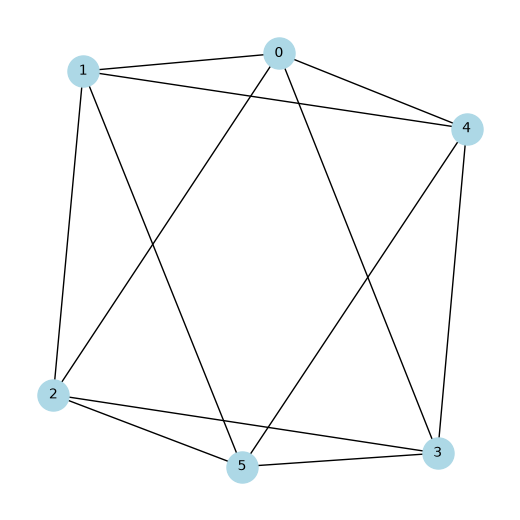

Let's modify this octahedron with Pachner Move 1-3 and visualize it!


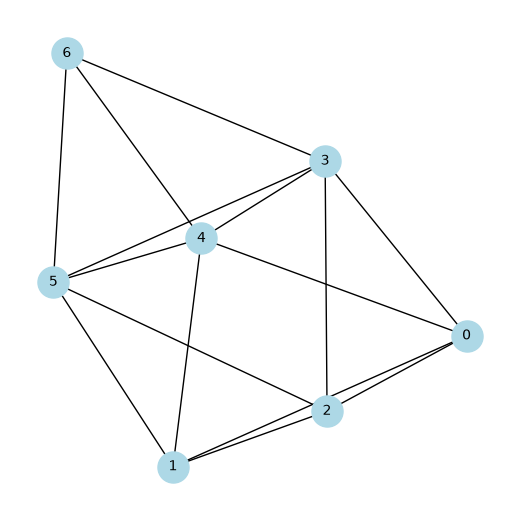

Let's return all back with Pachner move 3-1 and visualize it!


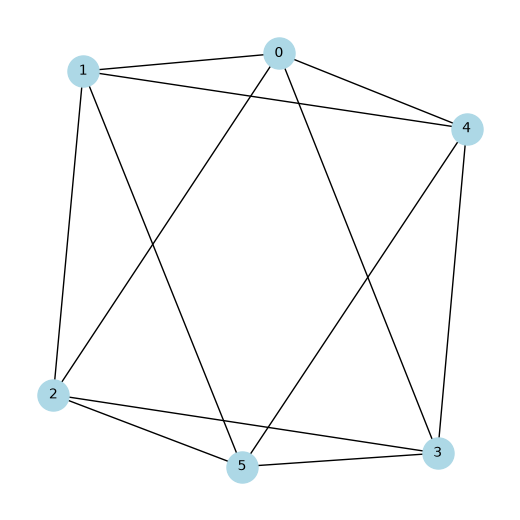

Let's calculate genus of this octahedron!
genus=0
Let's convert this figure to into the feature vector for MLP!
result=(8, 6, 12, 0, 0, 6, 0, 0, 4.0, 1.3333333333333333)


In [113]:
octahedron_ = [(0,10,20), (0,20,30), (0,30,40), (0,40,10),(50,20,10), (50,30,20), (50,40,30), (50,10,40)]

octahedron_relabeled = PySimplicial.utils.relabel(octahedron_)
print(f"Octahedron={octahedron_relabeled}")

print("Let's visualize the octahedron!")
PySimplicial.utils.visualize_triangulation_2D(octahedron_relabeled)

print("Let's modify this octahedron with Pachner Move 1-3 and visualize it!")
octahedron_modify = PySimplicial.utils.move_1_3(octahedron_relabeled)
PySimplicial.utils.visualize_triangulation_2D(octahedron_modify)

print("Let's return all back with Pachner move 3-1 and visualize it!")
octahedron_return = PySimplicial.utils.move_3_1(octahedron_modify)
PySimplicial.utils.visualize_triangulation_2D(octahedron_return)

print("Let's calculate genus of this octahedron!")
Compute_genus = PySimplicial.utils.compute_genus_2D(octahedron_return)
print(f"genus={Compute_genus}")

# genus=0


print("Let's convert this figure to into the feature vector for MLP!")
Converter = PySimplicial.utils.converter_for_mlp(octahedron_return, return_g=True) # return F, V, E, g, bins[0], bins[1], bins[2], bins[3], avg_degree, tpv ; 
# Where V = unique vertices, E = unique edges, F = number of faces, g = surface genus ; bins is Histogram of vertex degrees ; avg_degree is "2 * unique edges / unique vertices" ; tpv is "Number of faces / unique vertices"
print(f"result={Converter}")


# result=(8, 6, 12, 0, 0, 6, 0, 0, 4.0, 1.3333333333333333)
